# Multi-Factor Models
## 🎯 Learning Objectives

By the end of today you will be able to:

1. **Run and read a multi-factor regression** — CAPM, FF3, FF5, FF6
2. **Explain why alpha changes when you add a factor**, in both directions
3. **Argue that alpha is a property of a model, not of a strategy**
4. **Distinguish the time-series and cross-sectional approaches** to estimating
   the same thing
5. **Run a Fama-MacBeth regression** and interpret its slopes as portfolio returns

## 📋 Today's Plan

1. [From one factor to many](#many)
2. [Pitfall checklist](#pitfalls)
3. [🔄 Live Demo: the alpha ladder](#demo)
4. [Alpha is relative to a model — and ARKK vs Berkshire again](#relative)
5. [Two ways to estimate the same thing](#twoways)
6. [Fama-MacBeth](#fm)
7. [🎯 Challenge: your strategy up the ladder](#challenge) — *homework*
8. [Key takeaways](#takeaways)

---

## 🛠️ Setup

In [108]:
#@title Setup — run this first
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [11, 4.5]
import warnings; warnings.filterwarnings('ignore')
import pandas_datareader.data as web

BASE  = "https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data"
panel = pd.read_parquet(f"{BASE}/panel_backbone_1980_2000.parquet")
panel['date'] = pd.to_datetime(panel['date'])
f5  = web.DataReader('F-F_Research_Data_5_Factors_2x3','famafrench',start='1980-01-01')[0]/100
umd = web.DataReader('F-F_Momentum_Factor','famafrench',start='1980-01-01')[0]/100
for x in (f5, umd):
    x.index = pd.to_datetime(x.index.to_timestamp()) + pd.offsets.MonthEnd(0)
umd.columns = ['UMD']
FF = f5.join(umd, how='inner').loc['1980-01-31':'2000-12-31']

print(f"{len(FF)} months, factors: {[c for c in FF.columns if c != 'RF']}")

252 months, factors: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD']


---

## 1. From One Factor to Many <a id="many"></a>

In Lecture 4 you regressed on the market alone:

$$r^e_t = \alpha + \beta \, r^e_{m,t} + \varepsilon_t$$

That model says the only thing you can buy cheaply is market exposure. Lecture 5
said otherwise: there are whole families of characteristics that have paid, and
you can buy any of them in an ETF for a few basis points.

So the honest model has more terms:

$$r^e_t = \alpha + \sum_{k} \beta_k f_{k,t} + \varepsilon_t$$

### The standard ladder

| Model | Factors | Source |
|---|---|---|
| **CAPM** | Mkt-RF | Sharpe (1964) |
| **FF3** | + SMB (size), HML (value) | Fama-French (1993) |
| **FF5** | + RMW (profitability), CMA (investment) | Fama-French (2015) |
| **FF6** | + UMD (momentum) | Carhart (1997) |

Each factor is a **long-short portfolio** — exactly the thing you built in
Lecture 3. HML is long high book-to-market, short low. That is why the ladder
matters: every factor added is a bet somebody is already selling cheaply, and
your α has to be something *else*.

> **📌 Remember what α means now**
>
> α is the average return your strategy earned that **none of the factors in the
> model** can explain. Change the model, change the α. It is not a fixed
> property of your strategy.

---

## 🛡️ Pitfall Checklist for Multi-Factor Regressions <a id="pitfalls"></a>

| | Pitfall | What goes wrong | 🔍 How to detect |
|---|---|---|---|
| 1 | **Reporting α without saying which model** | "Our alpha is 6%" is meaningless alone | Always write "α relative to FF3" |
| 2 | **Adding factors until α disappears** | You can kill any α with enough factors — that's not a finding | Did you pick the model *before* looking? |
| 3 | **Correlated factors** | HML and CMA overlap; loadings get unstable and hard to read | Check the factor correlation matrix |
| 4 | **Comparing α across different samples** | FF5 starts later than FF3 in some datasets | Are all models fitted on identical months? |
| 5 | **Reading a loading as a claim about holdings** | β on HML = 1.2 doesn't mean you hold HML | It means your returns *co-move* with it |
| 6 | **Ignoring the t-stat on α while celebrating its size** | Big α on 60 months is noise | |t| > 2, and how many months? |



> Pitfall 2 is the subtle one. Ask an AI to "test whether this strategy has
> alpha" and it will pick a model for you — usually FF3 — without telling you
> that the choice determines the answer. You'll see today that the same strategy
> has α of +18% or +3% depending only on which model you asked for.

## Application to Book to Market

In [124]:


panel['me_l1'] = panel.groupby('permno')['me'].shift(1)   


def portfolio_formation(df, signal,ret='ret', ngroups=10):
    """Value-weighted decile portfolios, cut on NYSE breakpoints.

    The breakpoints are computed from NYSE stocks only (exchcd == 1); every
    stock is then placed in a bin using them. This is the Fama-French
    convention and it is not cosmetic here -- NYSE is about a quarter of the
    names in this panel, so cutting on all stocks lets the far more numerous
    small NASDAQ firms set the edges and packs the extreme deciles with
    microcaps.
    """
    # the interior cut points: 0.1, 0.2, ... 0.9 of the NYSE cross-section,
    # recomputed every month. .dropna() removes months with too few NYSE names.
    q = np.arange(1, ngroups) / ngroups
    # use the NYSE signal distribution
    edges = df[df['exchcd'] == 1].groupby('date')[signal].quantile(q).unstack().dropna()

    # a stock's bin is simply the number of that month's breakpoints it sits above
    df = df[df['date'].isin(edges.index)]
    grp = (df[signal].to_numpy()[:, None] > edges.loc[df['date']].to_numpy()).sum(axis=1)
    df = df.assign(signal_group=grp)          # assign, so the caller's frame is untouched

    # value weights: sum(ret * me) / sum(me) within each (month, bin)
    vw = (df.assign(_rw=df[ret] * df['me_l1'])
            .groupby(['date', 'signal_group'])[['_rw', 'me_l1']].sum())
    return (vw['_rw'] / vw['me_l1']).unstack(level=-1)


def long_short(sig):
    s = pd.read_parquet(f"{BASE}/signals/{sig}.parquet")
    d = panel.merge(s, on=['permno','date'], how='left').sort_values(['permno','date'])
    d['sig_l1'] = d.groupby('permno')[sig].shift(1)
    d = d.dropna(subset=['sig_l1', 'ret', 'me_l1'])
    p = portfolio_formation(d, 'sig_l1', ngroups=10)
    return (p[9] - p[0]).dropna()      # already dated by the month earned

In [125]:
r = long_short('BM') # create long-short portfolio based on Book-to-Market signal
df = pd.concat([r.rename('r_signal'), FF], axis=1).dropna() # merge returns with factors
Factors=['Mkt-RF']#,'SMB', 'HML', 'RMW', 'CMA', 'UMD'] # choose factors to include in regression
m = sm.OLS(df.r_signal, sm.add_constant(df[Factors])).fit()
m.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               r_signal   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     14.65
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           0.000164
Time:                        10:53:42   Log-Likelihood:                 465.29
No. Observations:                 251   AIC:                            -926.6
Df Residuals:                     249   BIC:                            -919.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0059      0.002      2.431      0.016       0.001       0.011
Mkt-RF        -0.2044      0.053     -3.828      0.000      -0.310      -0.099
==============================================================================
Omnibus:                        2.536   Durbin-Watson:                   1.454
Prob(Omnibus):                  0.281   Jarque-Bera (JB):                2.626
Skew:                           0.006   Prob(JB):                        0.269
Kurtosis:                       3.501   Cond. No.                         22.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

---

## 🔄 The Factor Ladder <a id="demo"></a>

Take the value long-short from Lecture 3 and run it up the ladder.

> **📝 Spec**
>
> Build the BM long-short. Regress it on CAPM, then FF3, then FF5, then
> FF6, all on the same months, each with an intercept. Report annualized α, its
> t-stat, R², and the loadings.

> **🤔 Predict.** As you add factors, does α go up, down, or stay put?

In [ ]:



MODELS = {'CAPM': ['Mkt-RF'],
          'FF3' : ['Mkt-RF','SMB','HML'],
          'FF5' : ['Mkt-RF','SMB','HML','RMW','CMA'],
          'FF6' : ['Mkt-RF','SMB','HML','RMW','CMA','UMD']}

def ladder(sig, show=True):
    r = long_short(sig)
    j = pd.concat([r.rename('y'), FF], axis=1).dropna()
    out = {}
    if show:
        print(f"{sig} long-short — raw return {j.y.mean()*12:+.2%}/yr, "
              f"{len(j)} months\n")
        print(f"{'model':7s}{'alpha/yr':>11s}{'t':>7s}{'R²':>7s}   loadings")
        print("-"*72)
    for name, cols in MODELS.items():
        m = sm.OLS(j.y, sm.add_constant(j[cols])).fit()
        out[name] = m
        if show:
            ld = "  ".join(f"{c}={m.params[c]:+.2f}" for c in cols)
            print(f"{name:7s}{m.params['const']*12:>10.2%}{m.tvalues['const']:>7.2f}"
                  f"{m.rsquared:>7.2f}   {ld}")
    return out

_ = ladder('BM')

BM long-short — raw return +5.23%/yr, 251 months

model     alpha/yr      t     R²   loadings
------------------------------------------------------------------------
CAPM        7.11%   2.43   0.06   Mkt-RF=-0.20
FF3        -1.22%  -0.73   0.71   Mkt-RF=+0.15  SMB=+0.65  HML=+1.21
FF5        -1.47%  -0.88   0.73   Mkt-RF=+0.18  SMB=+0.58  HML=+1.11  RMW=-0.15  CMA=+0.26
FF6        -0.62%  -0.35   0.73   Mkt-RF=+0.19  SMB=+0.57  HML=+1.07  RMW=-0.17  CMA=+0.28  UMD=-0.07


### The alpha didn't shrink. It vanished.



That is not surprising once you see it. HML *is* a value long-short — Fama and
French built it by sorting on book-to-market, which is exactly what we did. We
have rediscovered HML and then asked whether it beats HML.

What else is noteworthy about the loadings?

---

## 2. Alpha Is Relative to a Model <a id="relative"></a>

If adding factors always killed alpha, this would be a simple story. It doesn't.
Here are three more signals up the same ladder.

In [112]:
for s in ['GP', 'Mom12m', 'NOA']:
    _ = ladder(s); print()

GP long-short — raw return +6.57%/yr, 251 months

model     alpha/yr      t     R²   loadings
------------------------------------------------------------------------
CAPM        6.18%   2.55   0.00   Mkt-RF=+0.04
FF3         9.23%   3.93   0.12   Mkt-RF=-0.09  SMB=-0.19  HML=-0.43
FF5         5.82%   2.96   0.43   Mkt-RF=-0.08  SMB=+0.10  HML=-0.61  RMW=+0.82  CMA=+0.17
FF6         5.81%   2.83   0.43   Mkt-RF=-0.08  SMB=+0.10  HML=-0.61  RMW=+0.82  CMA=+0.17  UMD=+0.00

Mom12m long-short — raw return +19.80%/yr, 251 months

model     alpha/yr      t     R²   loadings
------------------------------------------------------------------------
CAPM       18.07%   4.07   0.02   Mkt-RF=+0.19
FF3        22.96%   5.22   0.10   Mkt-RF=-0.03  SMB=-0.07  HML=-0.64
FF5        22.25%   4.95   0.12   Mkt-RF=+0.03  SMB=-0.20  HML=-0.85  RMW=-0.26  CMA=+0.53
FF6         3.27%   1.65   0.85   Mkt-RF=-0.05  SMB=-0.15  HML=+0.02  RMW=+0.09  CMA=-0.05  UMD=+1.46

NOA long-short — raw return +10.30%/yr, 2

### Four signals, four completely different stories



> **💡 Key Insight: "does this strategy have alpha?" is not a well-posed question**
>

> **⚠️ Caution: which model should *you* use?**
>
> The defensible rule is to fix the model **before** you look, and to justify it
> by what an investor could actually buy cheaply. If a low-cost momentum ETF
> exists, UMD belongs in your model, and momentum's α is 3.5% not 18%.
>
> The indefensible version is running all four and reporting whichever is
> biggest. That is pitfall 2, and it is depressingly common.

### ARKK and Berkshire, again

In *Performance Evaluation* you took Berkshire apart against the market alone and
got β = 0.59, R² = 0.22, an appraisal ratio of 0.38. You are about to get 0.63,
0.22 and 0.40 instead — from the same fund, over the same years.

**The file changed, not the fund.** The monthly series used in Lecture 4 spans
398 months but contains only 279 of them: scattered single months are missing,
three or four a year, all the way through. Nobody chose those months — it is a
merge artifact — but a third of the sample was quietly gone. This lecture uses a
version rebuilt from the daily file, with all 397 months present. Berkshire
barely moves. ARKK, which had 59 of its 86 months, moves a lot.

Keep that in view while you read the table. The first thing that decides an
alpha is not the model — it is whether you looked at your data.


In [126]:
# Rebuilt from the daily file: all 397 months, no gaps. Funds compounded from
# daily returns, factors from Ken French's monthly files.
# Built by chapters/Finance/build_funds_monthly.py
funds = pd.read_pickle(f"{BASE}/df_WarrenBAndCathieW_monthly.pkl")
funds.columns = [c.strip() for c in funds.columns]      # 'Mom   ' has trailing spaces
SIX   = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
STATS = ['obs', 'alpha %', 't(alpha)', 'R2', 'appraisal']

# The point of this section is that the old file was missing months, so say so
# loudly rather than quietly reporting the old numbers if it loads anyway.
assert len(funds) == 397, f"expected the rebuilt 397-month file, got {len(funds)}"

def fit(fund, factors, data=funds, ppy=12):
    """One regression -> one row: fit stats, then the loadings."""
    d = data.dropna(subset=[fund])
    m = sm.OLS(d[fund] - d['RF'], sm.add_constant(d[factors])).fit()
    stats = pd.Series({'obs': m.nobs, 'alpha %': m.params['const'] * ppy * 100,
                       't(alpha)': m.tvalues['const'], 'R2': m.rsquared,
                       'appraisal': m.params['const'] * ppy / (m.resid.std() * np.sqrt(ppy))})
    return pd.concat([stats, m.params[factors]])

# Four regressions, four Series, one table. Worth reading slowly, because three
# separate pandas behaviours are doing the work:
#
# 1. pd.DataFrame(dict of Series) makes each KEY a column and each Series that
#    column's values. The Series are NOT the same length -- the market-only fit
#    returns 5 statistics + 1 loading, the six-factor fit 5 + 6.
#
# 2. Rows are aligned BY LABEL, never by position, and the row index becomes the
#    UNION of the four Series indexes. So 'HML' lands on the 'HML' row in every
#    column that has one, and the market-only columns get NaN on the five factor
#    rows they do not have. That is what prints as '.' below -- the gaps are
#    correct, not missing data.
#
# 3. Every key is a 2-tuple, so the columns come back as a MultiIndex. After .T
#    that is a two-level ROW index, which is why 'ARKK' is printed once and
#    spans its two rows.
#
# .T flips it so one row = one regression, which is the way you want to read it.
#
# [STATS + SIX] is NOT cosmetic. The union in step 2 comes back sorted
# alphabetically -- CMA, HML, Mkt-RF, Mom, R2, RMW, SMB, alpha %, appraisal,
# obs, t(alpha) -- so without it the loadings sit interleaved with the fit
# statistics. Passing the labels reindexes the columns into the order we want,
# and doubles as an explicit statement of what the table is supposed to contain.
table = pd.DataFrame({
    ('ARKK', 'market only'): fit('ARKK', ['Mkt-RF']),
    ('ARKK', 'six factors'): fit('ARKK', SIX),
    ('BRK',  'market only'): fit('BRK',  ['Mkt-RF']),
    ('BRK',  'six factors'): fit('BRK',  SIX),
}).T[STATS + SIX]

# statsmodels hands back floats throughout, so the month count arrives as 86.0
table['obs'] = table['obs'].astype(int)
print(table.round(2).to_string(na_rep='   .'))

# The two funds are not scored against the same factor environment.
arkk, brk = funds.dropna(subset=['ARKK']), funds.dropna(subset=['BRK'])
print("\nannualized factor premiums over each fund's own sample, % per year")
print(pd.DataFrame({
    f"ARKK  {arkk.index[0]:%Y-%m} to {arkk.index[-1]:%Y-%m}": arkk[SIX].mean() * 12 * 100,
    f"BRK   {brk.index[0]:%Y-%m} to {brk.index[-1]:%Y-%m}":   brk[SIX].mean() * 12 * 100,
}).round(1).to_string())

                  obs  alpha %  t(alpha)    R2  appraisal  Mkt-RF   SMB   HML   RMW   CMA   Mom
ARKK market only   86     4.53      0.58  0.57       0.23    1.54     .     .     .     .     .
     six factors   86     4.35      0.76  0.80       0.32    1.49  0.60 -0.95 -0.89 -0.37 -0.09
BRK  market only  397     7.27      2.29  0.22       0.40    0.63     .     .     .     .     .
     six factors  397     5.30      1.73  0.35       0.32    0.76 -0.39  0.51  0.25 -0.14 -0.00

annualized factor premiums over each fund's own sample, % per year
        ARKK  2014-11 to 2021-12  BRK   1988-12 to 2021-12
Mkt-RF                      14.4                       9.3
SMB                         -0.7                       1.3
HML                         -4.9                       1.1
RMW                          4.2                       4.3
CMA                         -1.5                       2.3
Mom                          1.7                       6.0


### Read the loadings before the alpha


**The second table is why you cannot compare the two strategy returns directly.** The funds
are not scored against the same factor environment. ARKK's 86 months ran a market
premium of **14.4%** a year; Berkshire's 397 ran **9.3%**. Value paid **−4.9%** a
year over ARKK's window and **+1.1%** over Berkshire's.

Put the loadings and the premiums together and the raw returns come apart:

| | excess return | from the factors | alpha |
|---|---|---|---|
| ARKK | 26.7%/yr | 22.3 | **4.3** |
| Berkshire | 13.2%/yr | 7.9 | **5.3** |

ARKK returned twice what Berkshire did and has the smaller alpha. Of its 26.7%,
**21.4 points are β = 1.49 against a market that paid 14.4%** — a levered bet in a
bull market. Another 4.6 points came from being *anti-value* (−0.95 on HML) in a
sample where value lost money. None of that is skill, and the model is right to
refuse to call it alpha.



The formula from *Performance Evaluation* carries over, with the best mix of the
factors in place of the market:

$$SR_{\max} = \sqrt{SR_F^2 + AR^2}$$

So the appraisal ratio against six factors is what a fund adds for someone who
already holds all six.

> **💡 Key Insight: the model decides the ranking**
>
> Note which way each one moved. Adding factors took Berkshire's number down and
> pushed ARKK's up. "More factors is a tougher test" is not a rule. Why?




### Would using daily data help?

**The betas move.** A daily beta measures how much of the factor move a fund picks
up *the same day*. Exposure that arrives with a lag — because the fund's stocks
or the factor's legs trade less often, or because the fund's positions reprice
slowly — shows up at the monthly horizon and not at the daily one. Daily betas
can be biased toward zero for exactly that piece. But more data--in each month we 
have 21 trading day-allow you to measure comovement better

**The factor premiums do not move.** averages do not care how frequently you sample

**The t-statistic can improve.** This is the part that surprises people.
The t on alpha is

$$t(\alpha) \;\approx\; AR \times \sqrt{\text{years of data}}$$

— the appraisal ratio times the square root of the *span*, not the square root of
the number of observations. Berkshire's 8,336 days and its 397 months cover the
same 33 years, so they give you about the same precision on alpha. Sampling more
often within a year tells you almost nothing new about the mean.

- However, if you estiamte betas better with daily data, the volatility of your residual woudl shrink.
This would enhance you AR and t-stat.

> **💡 Key Insight: frequency helps betas, not alphas**
>
> Going daily shrinks the standard errors on the **loadings** a lot — you are
> measuring co-movement, and there is 21× more co-movement to see. It can have a n indirect effect on  the standard error on **alpha**, which is a statement
> about an average return and mostly needs calendar time to be measured. But measurement of beta can help by shrinking the noise in the residuals.




---

## 3. Two Ways to Estimate the Same Thing <a id="twoways"></a>

Everything so far ran **one regression per strategy, through time**:

$$r_{p,t} = \alpha + \beta' f_t + \varepsilon_t \qquad t = 1 \dots T$$

That is the **time-series** approach. It needs the factor returns $f_t$ to
already exist — someone had to build HML before you could regress on it.

There is a second way. Run **one regression per month, across stocks**:

$$r_{i,t+1} = \gamma_{0,t} + Z_t' x_{i,t} + e_{i,t+1} \qquad i = 1 \dots N$$

Here $x_{i,t}$ is stock *i*'s characteristic — its book-to-market, its size —
and the *slope* $\gamma_t$ is estimated fresh every month.

| | Time-series | Cross-sectional |
|---|---|---|
| One regression per | strategy | month |
| You must supply | factor **returns** | firm **characteristics** |
| You estimate | betas, α | the factor return itself |
| Runs on | ~250 months | ~250 × 4,000 firm-months |



---

## 4. The Cross-sectional approach <a id="fm"></a>

The procedure is two steps and no more:

1. **Every month**, regress next month's excess returns across stocks on this month's
   characteristics. Keep the slopes.

2. The slopes tell us the excess returns on a pure play portfolio of the characteristic
3. **Average the slopes over time.** tell us the premium earned to trade this characteristic



In [122]:
# lets build the dataset with various charateristics, and their z-scores, to use in the multi-factor regression
d = panel.dropna(subset=['ret', 'me_l1']).copy()
for s in ['BM','GP','Mom12m']:
    d = d.merge(pd.read_parquet(f"{BASE}/signals/{s}.parquet"), on=['permno','date'], how='left')
d = d.sort_values(['permno','date'])

# Every characteristic is lagged one month; the return is this month's (Lecture 2)
d['logME'] = np.log(d['me_l1'])
for s in ['BM','GP','Mom12m']:
    d[s] = d.groupby('permno')[s].shift(1)

CH = ['logME','BM','GP','Mom12m']
d  = d.dropna(subset=CH + ['ret'])

# winsorize + z-score each month so the slopes are comparable across characteristics
for c in CH:
    d[c+'_z'] = d.groupby('date')[c].transform(
        lambda v: (v.clip(v.quantile(.01), v.quantile(.99)) - v.mean()) / v.std())
Z = [c+'_z' for c in CH]

d.head(5)

,permno,date,ret,me,prc,exchcd,shrcd,me_l1,BM,GP,Mom12m,logME,logME_z,BM_z,GP_z,Mom12m_z
14,10000,1987-05-31,-0.066667,851.59375,-0.21875,3,10,912.441345,-2.895161,0.243499,-0.937500,6.816124,-2.014995,-2.311275,-0.400530,-1.506344
25,10001,1987-01-31,-0.035714,6689.25000,6.75000,3,11,6937.000000,-0.104958,0.154795,0.199378,8.844625,-0.968480,0.692358,-0.685736,0.171260
26,10001,1987-02-28,-0.074074,6193.75000,6.25000,3,11,6689.250000,-0.104958,0.154795,0.217369,8.808257,-1.030260,0.695484,-0.691798,0.420486
27,10001,1987-03-31,0.036800,6317.62500,6.37500,3,11,6193.750000,-0.104958,0.154795,0.150414,8.731296,-1.106901,0.707298,-0.691006,0.154832
28,10001,1987-04-30,-0.039216,6069.87500,-6.12500,3,11,6317.625000,-0.104958,0.154795,0.039015,8.751099,-1.114735,0.712780,-0.687230,-0.134810


In [132]:
# we can use our portfolio_formation function to create decile portfolios based on any of the characteristics,
#  and then look at the average characteristic value in each decile instead of the return

X=portfolio_formation(d,'BM',ret='GP', ngroups=10)
X.mean()

# what this tell us?

signal_group
0    0.557854
1    0.473429
2    0.441512
3    0.380991
4    0.338305
5    0.280226
6    0.249998
7    0.220947
8    0.224993
9    0.228655
dtype: float32

- The cross-sectional regression deals with this problem by perfectly heding out the other characteristics

- The result is a pure-play portfolio on the characteristic

> **💡 Key Insight: the slope IS a portfolio return**
>
> Not "behaves like." **Is.** Write the month-*t* regression in matrix form with
> characteristics $X$ and returns $r$, and OLS gives
> $Z_t = (X'X)^{-1}X'r$ — which is a fixed matrix times the vector of
> returns. That is the definition of a portfolio return, and $(X'X)^{-1}X'$ is
> the matrix of portfolio weights. You do not have to take this on faith; it
> falls out of the formula.
>
> So $Z_t$ is the return, in month *t*, of a portfolio with one unit of
> exposure to that characteristic and zero exposure to the others. It is a
> **pure play** — the closest thing to "what did value pay this month, holding
> size and profitability fixed."
>
> A decile sort can't do that. Sorting on book-to-market also sorts, partly, on
> size. A cross-sectional regression controls for the others by construction.

This is **Fama-MacBeth** (1973), and it is one of the most-used procedures in
empirical finance.

In [ ]:
#@title 🔒 Reference implementation — later cells use `d`, `Z` and `G`


# STEP 1 — one cross-sectional regression per month
slopes = []
for dt, g in d.groupby('date'):
    if len(g) < 100: continue
    slopes.append(sm.OLS(g['ret'], sm.add_constant(g[Z])).fit().params.rename(dt))
G = pd.DataFrame(slopes)

print(f"Step 1: {len(G)} monthly cross-sectional regressions, "
      f"~{len(d)/d.date.nunique():.0f} stocks each\n")

# STEP 2 — average the slopes; t-stat from their time-series variation
print(f"{'characteristic':16s}{'slope/month':>13s}{'annualized':>12s}{'t-stat':>9s}")
print("-"*50)
for c in ['const'] + Z:
    v = G[c]
    print(f"{('intercept' if c=='const' else c[:-2]):16s}"
          f"{v.mean():>13.5f}{v.mean()*12:>11.2%}{v.mean()/v.std()*np.sqrt(len(v)):>9.2f}")
    


Step 1: 250 monthly cross-sectional regressions, ~3885 stocks each

characteristic    slope/month  annualized   t-stat
--------------------------------------------------
intercept             0.01255     15.06%     3.57
logME                -0.00259     -3.11%    -1.77
BM                    0.00467      5.60%     5.02
GP                    0.00234      2.81%     3.83
Mom12m                0.00457      5.48%     3.63


<Axes: >

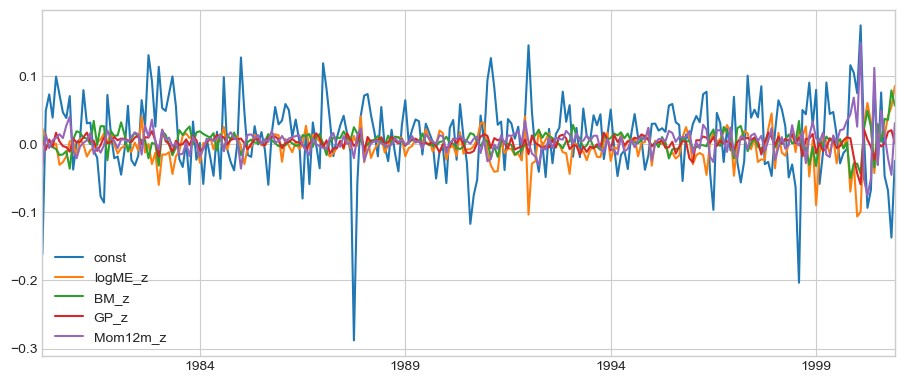

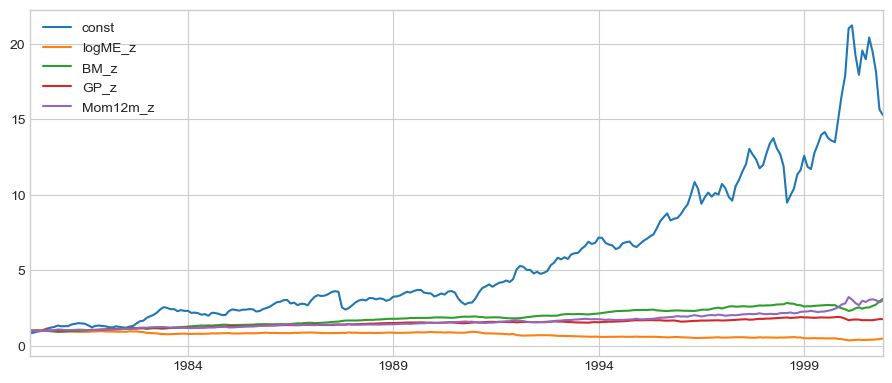

In [116]:

(G).plot()


(1+G).cumprod().plot()

### Reading the output

Each row is the return to a portfolio that is **+1 standard deviation** of that
characteristic and **flat on the other three**.


> **📌 Remember: the intercept is not alpha**
>
> The 14.96% intercept is the return of a stock with *average* values of every
> characteristic. It is roughly the market return, not a mispricing.

> **📎 What you do with it next**
>
> The time-series model gave you a *hedge*: hold the asset, short β units of the
> factor, and the systematic part cancels (Lecture 4). The cross-sectional model
> has an exact counterpart — compute the return your portfolio's
> **characteristics** imply, and subtract it. That's a **characteristic-adjusted
> return**, and it's hedging without ever estimating a time-series beta.
>
> It needs the multi-asset machinery, so it's Lecture 7.

> **🤔 Compare with the sort**
>
> In Lecture 3, the BM long-short under the standard
> convention (NYSE breakpoints, value-weighted) gave +5.27%/yr. Fama-MacBeth gives +5.55%/yr
> — close, but not identical, and the FM version *holds size, profitability and
> momentum fixed* while the sort does not. When they disagree sharply, it means
> your sort was picking up something other than the characteristic you sorted
> on.

### Some "intuition"

The box above states it with $(X'X)^{-1}X'$. Here is the identical fact using
nothing but sums. It is worth seeing once, because it is two lines and it
explains everything the procedure does.

Take a single month: returns $r_i$ across stocks, one characteristic $x_i$. The
OLS slope is

$$\hat{Z} = \frac{\sum_i (x_i - \bar{x})(r_i - \bar{r})}{\sum_i (x_i - \bar{x})^2}$$

Now use the one fact that makes it collapse: $\sum_i (x_i - \bar{x}) = 0$. So the
$\bar{r}$ piece contributes $-\bar{r}\sum_i (x_i - \bar{x}) = 0$ and just drops:

$$\hat{Z} = \sum_i w_i\, r_i \qquad\text{where}\qquad w_i = \frac{x_i - \bar{x}}{\sum_j (x_j - \bar{x})^2}$$

**Look at what is inside $w_i$: characteristics, and nothing else.** No returns.
Fix the characteristics at the start of the month and the slope is a fixed set of
weights applied to whatever returns happen to show up. That is what a portfolio
is, and $w$ is its weights.

Two properties follow, each one line of arithmetic:

$$\sum_i w_i = 0 \qquad\qquad \sum_i w_i x_i = 1$$

The first says the long and short sides are the same size — it costs nothing to
hold. The second says it carries exactly one unit of the characteristic.





**With more than one characteristic**, still no matrices. One sentence: *to get the slope on $x_1$ when other characteristics are in the
regression, first strip them out of $x_1$* — regress $x_1$ on the others and keep
the residual $\tilde{x}_1$ — *then the same formula applies*:

$$\hat{Z}_1 = \sum_i w_i\, r_i \qquad\text{where}\qquad w_i = \frac{\tilde{x}_{1,i}}{\sum_j \tilde{x}_{1,j}^2}$$

and the two properties become

$$\sum_i w_i x_1 = 1 \qquad\qquad \sum_i w_i x_k = 0 \;\text{ for every other } k$$

So "holding size and profitability fixed" stops being a slogan. It is a
statement about a portfolio's exposures, and you can check it with a sum — which
is exactly what we do below.


### Checking it on one month

Two lines of algebra deserve one line of code. Below: build $w$ from
characteristics alone, then check it reproduces the slope `statsmodels` reported,
carries one unit of book-to-market and zero of everything else — and compare it
with what a decile sort would have held instead.


In [141]:
# One month, one characteristic. Nothing below touches returns until the very
# last step -- the weights are built from characteristics only.
month  = '2000-11-30'
g      = d[d['date'] == month].copy()
others = ['logME_z', 'GP_z', 'Mom12m_z']

#  strip the other three characteristics out of BM, then the
# two-line formula applies to whatever is left of it.
x = sm.OLS(g['BM_z'], sm.add_constant(g[others])).fit().resid
g['w_reg'] = x / (x**2).sum()

print(f"{month}, {len(g):,} stocks")
print(f"  sum of the weights             {g['w_reg'].sum():+.1e}   <- zero cost")
print(f"  w'r, weighted sum of returns   {(g['w_reg'] * g['ret']).sum():+.6f}")
print(f"  the OLS slope on BM that month {G.loc[month, 'BM_z']:+.6f}   <- the same number")
print(f"  w'GP, weighted sum of GP characteristic   {(g['w_reg'] * g['GP_z']).sum():+.6f} <- No other factor exposure")
print(f"  w'BM, weighted sum of BM characteristic   {(g['w_reg'] * g['BM_z']).sum():+.6f} <- Factore exposure of 1 on the factor!")


2000-11-30, 4,020 stocks
  sum of the weights             +0.0e+00   <- zero cost
  w'r, weighted sum of returns   +0.079113
  the OLS slope on BM that month +0.079113   <- the same number
  w'GP, weighted sum of GP characteristic   -0.000000 <- No other factor exposure
  w'BM, weighted sum of BM characteristic   +1.000000 <- Factore exposure of 1 on the factor!


## 5. Characteristic Adjusted Returns


- Consider a portfolio of two stocks with weights w1 and w2 and these stocks have characteristics X1 and X2.
- Then this portfolio has characteristic Xp=w1*X1+w2*X2
- The characteristic implied return is then $Xp@Z_t$
- For example if we had three characteristics: value, momentum, and size we would have

$$ xp(size)Z(size)+xp(momentum)*Z(momentum)+xp(value)*Z(value)$$

This is the characteristic equivalent portfolio, so the characteristic-adjusted returns is

$$rp-Xp@Z_t$$

What would we need from ARK or BRK to do that?

What are the advantadges of this approach?

What are the weakness?



---

## 🎯 Challenge: Your Strategy Up the Ladder <a id="challenge"></a>

*Homework — due before Lecture 7.*

Take the signal your group has carried since the sorts lecture and run it up the
same ladder we ran `BM` and momentum up. Then work out which exposure did the
damage.

`long_short()` and `ladder()` are defined above and you may use them as they are.

### Q1 — The alpha ladder

Build your long-short, fit all four models, and fill in the **annualized alpha**
at each rung. The Series is made for you; put each number in its slot.

In [ ]:
# === EDIT THIS CELL: your signal ===
MY_SIGNAL = ____

# Your work here


# Required output — the annualized alpha at each rung:
alpha = pd.Series(index=['CAPM', 'FF3', 'FF5', 'FF6'], dtype=float)

alpha['CAPM'] = ____
alpha['FF3']  = ____
alpha['FF5']  = ____
alpha['FF6']  = ____

alpha

### Q2 — The loadings

Now the loadings, at **every** rung — one row per model, one column per factor.
A model that does not include a factor leaves that cell empty, so the CAPM row
has one number and the FF6 row has six.

In [ ]:
# Required output — one row per model, one column per factor:
loadings = pd.DataFrame(index=['CAPM', 'FF3', 'FF5', 'FF6'],
                        columns=['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD'],
                        dtype=float)

loadings.loc['CAPM', ['Mkt-RF']]                                    = ____
loadings.loc['FF3',  ['Mkt-RF', 'SMB', 'HML']]                      = ____
loadings.loc['FF5',  ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]        = ____
loadings.loc['FF6',  ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD']] = ____

loadings

### Q3 — What each factor paid

A loading only matters if the factor earned something. Fill in each factor's
**annualized premium** over your sample — its average monthly return times 12.

In [ ]:
# Required output — the annualized premium of each factor:
premiums = pd.Series(index=['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD'], dtype=float)

premiums['Mkt-RF'] = ____
premiums['SMB']    = ____
premiums['HML']    = ____
premiums['RMW']    = ____
premiums['CMA']    = ____
premiums['UMD']    = ____

premiums

### Q4 — The memo

> **📝 Your task — maximum eight sentences**
>
> Your PM already knows the raw return. Tell them what survives the factors.
>
> Which rung moved your alpha the most, and which loading did it? A loading times
> its factor's premium is the part of your raw return that exposure accounts for,
> so use those numbers rather than the loadings alone. Say in plain language what
> holding that exposure means — what is your strategy actually long, and short?
>
> If your alpha *rose* somewhere on the ladder, that is a negative loading on a
> factor that paid, and it deserves a sentence of its own.
>
> Finish with the number you would put in front of an investment committee, and
> why that rung rather than the one above it.

In [ ]:
MEMO = """
Write your memo here. Don't delete the surrounding triple quotes.
"""
print(MEMO)

---

## 📤 Submission <a id="submit"></a>

In [ ]:
# === 📤 SUBMISSION CELL — Run this last ===
import json, base64, hashlib, datetime as dt

required = ["MY_SIGNAL", "alpha", "loadings", "premiums", "MEMO"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"\n❌ Missing before submission: {missing}")
blank = ([f"alpha[{k!r}]" for k in alpha.index if pd.isna(alpha[k])] +
         [f"premiums[{k!r}]" for k in premiums.index if pd.isna(premiums[k])] +
         [f"loadings.loc[{m!r}]" for m in loadings.index if loadings.loc[m].notna().sum() == 0])
if blank:
    raise ValueError(f"\n❌ Still empty: {blank}")

payload = {
    "assignment": "L6_MultiFactor_AI",
    "ts": dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds").replace("+00:00", "Z"),
    "signal": MY_SIGNAL,
    "answers": {
        "alpha":    {k: float(v) for k, v in alpha.items()},
        "loadings": {m: {f: float(v) for f, v in loadings.loc[m].dropna().items()}
                     for m in loadings.index},
        "premiums": {k: float(v) for k, v in premiums.items()},
    },
    "memo": MEMO.strip(),
}
blob = json.dumps(payload, sort_keys=True)
checksum = hashlib.sha256(blob.encode()).hexdigest()[:8]
token = f"UG54::{checksum}::{base64.b64encode(blob.encode()).decode()}"

print("=" * 72)
print("📋  COPY THE LINE BELOW AND PASTE INTO THE SUBMISSION FORM")
print("=" * 72)
print(token)
print("=" * 72)
print("Submission form: https://forms.gle/yazZ8bbatL87jdJi7")

---

## 🧠 Key Takeaways <a id="takeaways"></a>

1. **Every factor in the model is a long-short portfolio** — the thing you built
   in Lecture 3. Adding one asks "can you beat *that* too?"

2. **α is a property of (strategy, model), not of a strategy.** Momentum's α is
   +18% or +3.5% depending only on whether UMD is in the model.

3. **Never report an alpha without naming the model.** The same goes for the
   appraisal ratio: against six factors ARKK's rises from 0.23 to 0.32 and
   Berkshire's falls from 0.40 to 0.32 — a clear ranking against the market
   becomes a tie.

4. **Alpha can grow when you add a factor.** GP's α rises under FF3 because it
   loads *negatively* on HML.

5. **Name the horizon too.** Estimating the same six-factor model daily instead
   of monthly moves Berkshire's RMW loading from +0.24 to −0.17. Higher frequency
   sharpens the betas and does nothing for the alpha's t-statistic, which needs
   calendar span, not observations. Dimson lags let you test *why* the two
   horizons disagree instead of just reporting that they do.

6. **Check the file before you trust the number.** The monthly series used in
   Lecture 4 was missing a third of its months. Berkshire's appraisal ratio moved
   from 0.38 to 0.40 once they were restored; ARKK's six-factor number moved from
   0.63 to 0.32.

7. **Fix the model before you look.** Justify it by what an investor could
   actually buy cheaply. Running all four and reporting the best is not analysis.

8. **Two estimation routes to the same object.** Time-series needs factor
   returns and gives you betas; cross-sectional needs characteristics and gives
   you the factor return.

9. **A Fama-MacBeth slope is a portfolio return** — a pure play on one
   characteristic, holding the others fixed. That's something a sort cannot do.

10. **The FM t-stat comes from variation across months**, not from the thousands
   of stocks inside any single month.

---

### Next class

Everything so far has been in-sample. We have run the same data through four
models and picked the interesting results. Next: what that does to a t-statistic,
and how you would ever know whether any of it is real.

---

## 📎 Appendix <a id="appendix"></a>

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 📎 APPENDIX — Belt-and-Suspenders Data Loading
# ═══════════════════════════════════════════════════════════════════════
#   panel = pd.read_parquet(f"{BASE}/panel_backbone_1980_2000.parquet")
#
# Factors come live from Ken French. Prompt:
# "Using pandas-datareader fetch F-F_Research_Data_5_Factors_2x3 and
#  F-F_Momentum_Factor, monthly, from 1980. Convert PeriodIndex to month-end,
#  divide by 100, and join them."
def fetch_ff6():
    import pandas_datareader.data as web
    f5  = web.DataReader('F-F_Research_Data_5_Factors_2x3','famafrench',start='1980-01-01')[0]/100
    umd = web.DataReader('F-F_Momentum_Factor','famafrench',start='1980-01-01')[0]/100
    for x in (f5, umd):
        x.index = pd.to_datetime(x.index.to_timestamp()) + pd.offsets.MonthEnd(0)
    umd.columns = ['UMD']
    return f5.join(umd, how='inner')

# Note: Ken French labels the momentum factor 'Mom   ' with trailing spaces in
# some releases. We rename to 'UMD' on load rather than trusting the label.
